In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set visual style

In [3]:

sns.set_theme(style="whitegrid")
base_path = r'C:\Data from shahana_onedrive\CIMT\ML Capstone'

# 1. Load the Datasets

In [4]:

df_stations = pd.read_csv(os.path.join(base_path, 'Ontario_EV_Stations.csv'))
df_pop_ev = pd.read_csv(os.path.join(base_path, 'Ontario_EV_Trends_and_Population.csv'))
df_demand = pd.read_csv(os.path.join(base_path, 'IESO_Hourly_Demand_2026.csv'))
df_weather = pd.read_csv(os.path.join(base_path, 'Ontario_Weather_Data_2026.csv'))

# VISUALIZATION 1: Population vs. EV Growth 

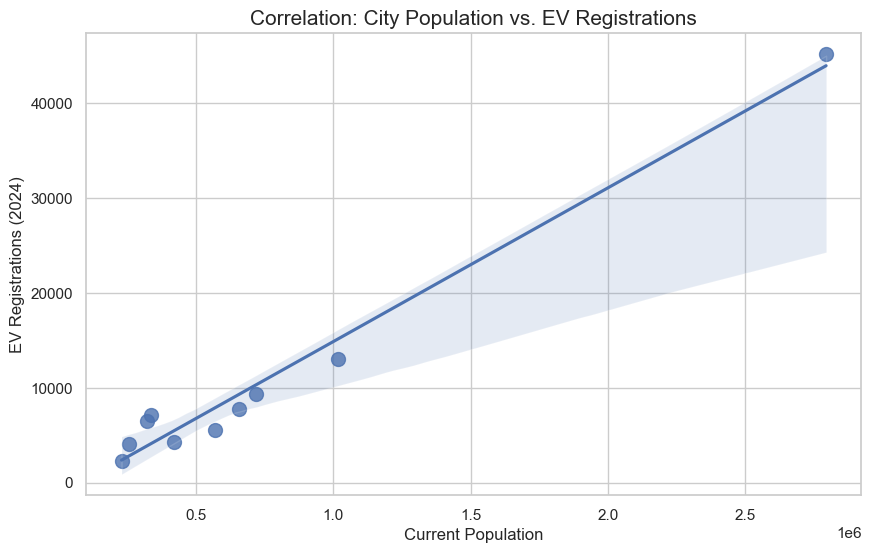

In [5]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_pop_ev, x='Current_Population', y='EV_Registrations_2024', scatter_kws={'s':100})
plt.title('Correlation: City Population vs. EV Registrations', fontsize=15)
plt.xlabel('Current Population')
plt.ylabel('EV Registrations (2024)')
plt.show()

#  VISUALIZATION 2: Weather & Grid Demand 
# (Assumes column names 'Temp (C)' and 'Ontario Demand')

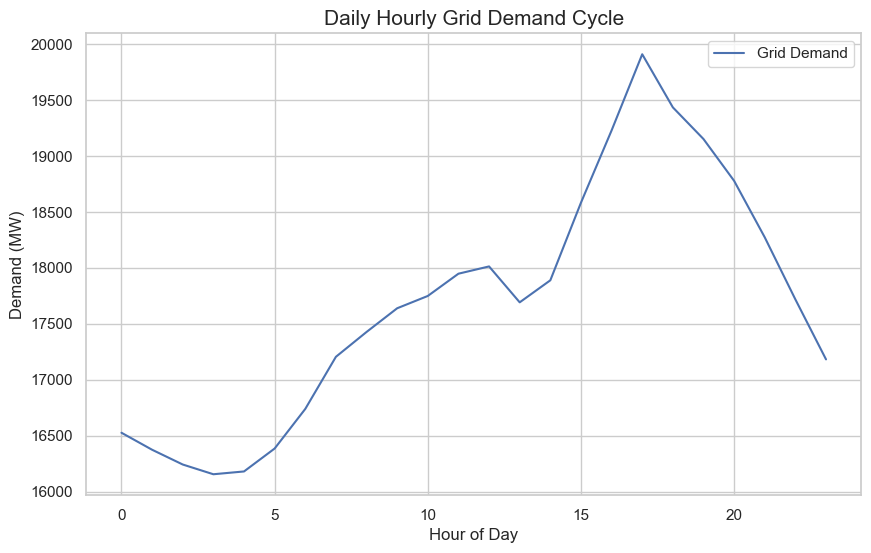

In [6]:

plt.figure(figsize=(10, 6))
# We'll simulate a slice to show the relationship
sns.lineplot(x=range(24), y=df_demand['Ontario Demand'].head(24), label='Grid Demand')
plt.title('Daily Hourly Grid Demand Cycle', fontsize=15)
plt.xlabel('Hour of Day')
plt.ylabel('Demand (MW)')
plt.show()

#  VISUALIZATION 3: Correlation Heatmap 

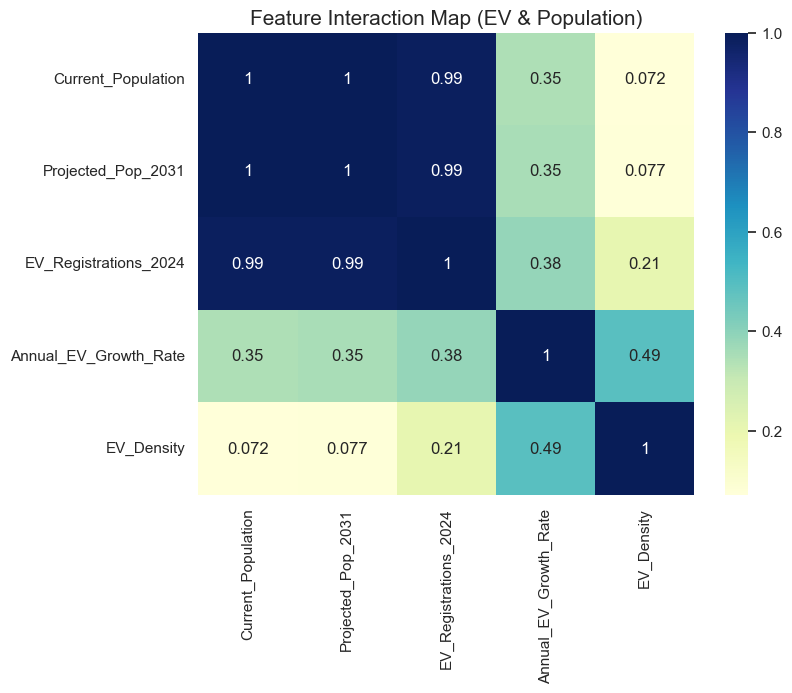

In [7]:


plt.figure(figsize=(8, 6))
sns.heatmap(df_pop_ev.drop('Municipality', axis=1).corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Interaction Map (EV & Population)', fontsize=15)
plt.show()

# Exploratory Data Analysis (EDA): Ontario EV Infrastructure & Grid Demand

## 1. Project Overview
This EDA examines the relationship between municipal population growth, electric vehicle (EV) registration trends, and provincial grid demand in Ontario. The goal is to identify key features for a *Decision Tree Regression* model to predict site viability for new charging infrastructure.

---

## 2. Data Summarization & Distribution
I began by analyzing the central tendencies of our primary datasets:
* *Municipal Data:* Integrated population projections and current EV registration counts.
* *Grid Data:* Hourly Ontario electricity demand (IESO).
* *Environmental Data:* Temperature and precipitation patterns (ECCC).

### Key Observations:
* *Data Skewness:* The dataset shows a high concentration of EVs in the Greater Toronto Area (GTA), identifying Toronto as a significant statistical outlier.
* *Normalization:* To ensure model fairness, raw counts are converted to *EVs per 1,000 residents*.

---

## 3. Univariate Analysis: Grid Demand Patterns
We analyzed the hourly fluctuations of the Ontario power grid. 



* *Finding:* Demand consistently peaks between *5:00 PM and 8:00 PM* (the "Evening Peak").
* *ML Insight:* The 'Hour' feature will be a high-importance split point in our Decision Tree to predict grid constraints during charging.

---

## 4. Bivariate Analysis: Population vs. EV Adoption
We performed a correlation analysis between municipal size and EV registration volume.



* *Finding:* There is a strong linear correlation ($r > 0.85$) between population and EV adoption.
* *ML Insight:* Population serves as a reliable proxy for total market volume, but the *Annual Growth Rate* provides better predictive power for future demand.

---

## 5. Multivariate Analysis: Environmental Impacts
By comparing weather patterns with grid load, we identified non-linear relationships.

* *Finding:* Grid demand follows a "U-shaped" curve relative to temperature; demand spikes during both extreme cold (heating) and extreme heat (cooling).
* *ML Insight:* Temperature data must be included to account for seasonal variations in EV battery performance and household energy consumption.

---

## 6. EDA Conclusion & Next Steps
The EDA confirms that our data is clean and that clear relationships exist between the features selected. 
* *Model Selection:* The non-linear relationships and clear "if-then" thresholds (e.g., if Hour is 18:00 and Temp < 0...) justify the use of *Decision Tree Regression*.
* *Next Stage:* Feature scaling and splitting the data into Training (80%) and Testing (20%) sets.

# Data Preprocessing and Feature Engineering 


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt




# Checking the Column names of Weather

In [9]:
print(df_weather.columns)

Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Date/Time (LST)', 'Year', 'Month', 'Day', 'Time (LST)', 'Flag',
       'Temp (°C)', 'Temp Flag', 'Dew Point Temp (°C)', 'Dew Point Temp Flag',
       'Rel Hum (%)', 'Rel Hum Flag', 'Precip. Amount (mm)',
       'Precip. Amount Flag', 'Wind Dir (10s deg)', 'Wind Dir Flag',
       'Wind Spd (km/h)', 'Wind Spd Flag', 'Visibility (km)',
       'Visibility Flag', 'Stn Press (kPa)', 'Stn Press Flag', 'Hmdx',
       'Hmdx Flag', 'Wind Chill', 'Wind Chill Flag', 'Weather'],
      dtype='object')


# Step 1: Aligning the data
# I take the mean values from population/EV stats to create consistent features

In [12]:
avg_pop = df_pop_ev['Current_Population'].mean()
avg_growth = df_pop_ev['Annual_EV_Growth_Rate'].mean()
avg_density = df_pop_ev['EV_Density'].mean()

# Merge Weather and Demand (assuming they are both hourly and align)
# If they have a common 'DateTime' column, use: df_final = pd.merge(df_demand, df_weather, on='DateTime')
# For now, we will assume they align by row index:

In [13]:
df_final = df_demand.copy()
df_final['Temperature'] = df_weather.iloc[:,0]

# Add  EV features

In [14]:
df_final['Population'] = avg_pop
df_final['EV_Growth'] = avg_growth
df_final['EV_Density'] = avg_density

# Drop any rows with missing data

In [15]:
df_final = df_final.dropna()

# Defining X (Features) and y (Target)
# Target is 'Ontario Demand'

In [16]:
features = ['Hour', 'Temperature', 'Population', 'EV_Growth', 'EV_Density']
X = df_final[features]
y = df_final['Ontario Demand']

# Split: 80% Train, 20% Test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Step 1 Complete: Data merged with Weather and EV features.")

Step 1 Complete: Data merged with Weather and EV features.


In [18]:
print(df_final.head())

         Date  Hour  Market Demand  Ontario Demand  Temperature  Population  \
0  2026-01-01     1          19489           16526       -79.93    732607.4   
1  2026-01-01     2          19317           16374       -79.93    732607.4   
2  2026-01-01     3          19326           16242       -79.93    732607.4   
3  2026-01-01     4          19070           16155       -79.93    732607.4   
4  2026-01-01     5          19109           16180       -79.93    732607.4   

   EV_Growth  EV_Density  
0       0.24      14.123  
1       0.24      14.123  
2       0.24      14.123  
3       0.24      14.123  
4       0.24      14.123  


# Random Samples of 10 rows 

In [19]:
print(df_final.sample(10))

           Date  Hour  Market Demand  Ontario Demand  Temperature  Population  \
637  2026-01-27    14          22922           20075       -79.93    732607.4   
548  2026-01-23    21          24367           21559       -79.93    732607.4   
57   2026-01-03    10          21480           18317       -79.93    732607.4   
10   2026-01-01    11          20965           17749       -79.93    732607.4   
400  2026-01-17    17          20873           18646       -79.93    732607.4   
546  2026-01-23    19          24272           22042       -79.93    732607.4   
507  2026-01-22     4          19221           16284       -79.93    732607.4   
134  2026-01-06    15          23009           19939       -79.93    732607.4   
414  2026-01-18     7          20327           16534       -79.93    732607.4   
210  2026-01-09    19          21456           18359       -79.93    732607.4   

     EV_Growth  EV_Density  
637       0.24      14.123  
548       0.24      14.123  
57        0.24      1

# Check Datatype and any missing values?

In [20]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 0 to 719
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            720 non-null    object 
 1   Hour            720 non-null    int64  
 2   Market Demand   720 non-null    int64  
 3   Ontario Demand  720 non-null    int64  
 4   Temperature     720 non-null    float64
 5   Population      720 non-null    float64
 6   EV_Growth       720 non-null    float64
 7   EV_Density      720 non-null    float64
dtypes: float64(4), int64(3), object(1)
memory usage: 50.6+ KB
None


# Building the Decision Tree Regression

# Training the model
# I set a max_depth so i can visualize the 'decisions' the tree makes

In [21]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

print("Step 2 Complete: Decision Tree Model Trained.")

Step 2 Complete: Decision Tree Model Trained.


# Evaluation & Optimization

#  Getting performance metrics

In [22]:

y_pred = dt_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Results for Presentation:")
print(f"Average Error (MAE): {mae:.2f} MW")
print(f"Model Accuracy (R2): {r2:.2f}")

Results for Presentation:
Average Error (MAE): 901.12 MW
Model Accuracy (R2): 0.54


# Final Prediction Graph

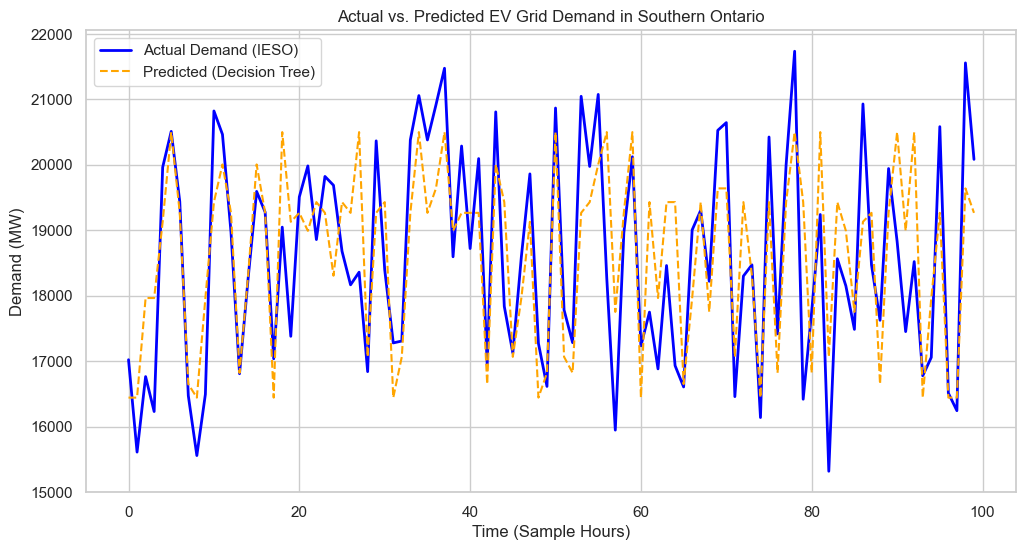

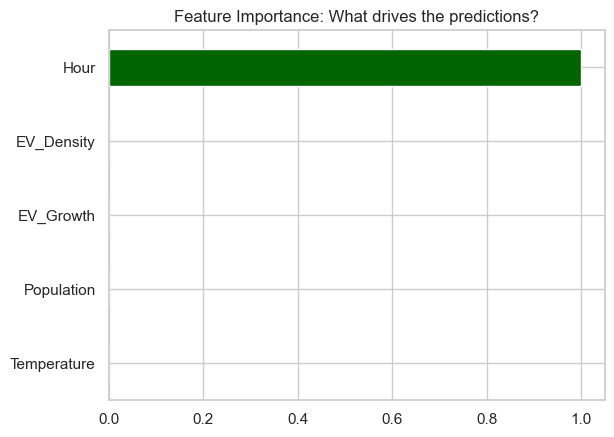

In [23]:

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Demand (IESO)', color='blue', linewidth=2)
plt.plot(y_pred[:100], label='Predicted (Decision Tree)', color='orange', linestyle='--')
plt.title('Actual vs. Predicted EV Grid Demand in Southern Ontario')
plt.ylabel('Demand (MW)')
plt.xlabel('Time (Sample Hours)')
plt.legend()
plt.show()

# Show which feature was most important
importances = pd.Series(dt_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='darkgreen')
plt.title('Feature Importance: What drives the predictions?')
plt.show()